In [38]:
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time

plt.style.use('classic')
%matplotlib inline

# =====================================================================
# FLAGS
# =====================================================================
display_output = True
save_progress = True
verbose_output = True

# =====================================================================
# REPORTER
# =====================================================================
_best_fitness_ever = float('inf')
_best_image_ever = None

def reporter(metrics, evo):
    global _best_fitness_ever, _best_image_ever

    gen = metrics["num-generations"]
    elite_img = draw_voronoi_image(
        evo.elite, evo.reference_image.width, evo.reference_image.height,
        scale=IMAGE_SHRINK_SCALE
    )

    if evo.elite_fitness < _best_fitness_ever:
        _best_fitness_ever = evo.elite_fitness
        _best_image_ever = elite_img.copy()

    if save_progress and gen % 50 == 0:
        elite_img.save(
            f"./img/van_gogh_intermediate_{evo.seed}_{evo.population_size}_"
            f"{evo.crossover_method}_{evo.num_points}_{evo.initialization}_"
            f"{evo.generation_budget}_{gen:05d}.png"
        )

    if display_output and gen % 50 == 0:
        avg_fitness = np.mean(evo.population.fitnesses)
        worst_fitness = np.max(evo.population.fitnesses)

        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(evo.reference_image)
        axes[0].set_title("Reference", fontsize=11)
        axes[0].axis('off')
        axes[1].imshow(elite_img)
        axes[1].set_title(f"Elite — fitness {evo.elite_fitness:.2f}", fontsize=11)
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

        print(f"{'='*60}")
        print(f"Generation  : {gen}")
        print(f"Elite       : {evo.elite_fitness:.4f}  (best ever: {_best_fitness_ever:.4f})")
        print(f"Population  : avg {avg_fitness:.4f}  |  worst {worst_fitness:.4f}")
        print(f"Spread      : {worst_fitness - evo.elite_fitness:.4f}")
        print(f"Points      : {evo.num_points}")
        print(f"{'='*60}")

# =====================================================================
# RUN
# =====================================================================
def run_algorithm(settings):
    global _best_fitness_ever, _best_image_ever
    _best_fitness_ever = float('inf')
    _best_image_ever = None

    seed, population_size, crossover_method, num_points, initialization, generation_budget = settings
    start = time()

    evo = Evolution(
        num_points,
        REFERENCE_IMAGE,
        population_size=population_size,
        generation_reporter=reporter,
        crossover_method=crossover_method,
        seed=seed,
        initialization=initialization,
        generation_budget=generation_budget,
        num_features_mutation_strength=0.07, 
        selection_name='tournament_2', 
        mutation_probability=0.01,      
        enable_spatial_adaptation=True,     
        stabilization_phase_duration=77,    
        mutation_factor=0.27,                  
        verbose=verbose_output
    )
    data = evo.run()
    time_spent = time() - start
    print(f"Done: seed {seed} - pop {population_size} - crossover {crossover_method} "
          f"- points {num_points} - init {initialization} - {int(time_spent)}s")
    return data


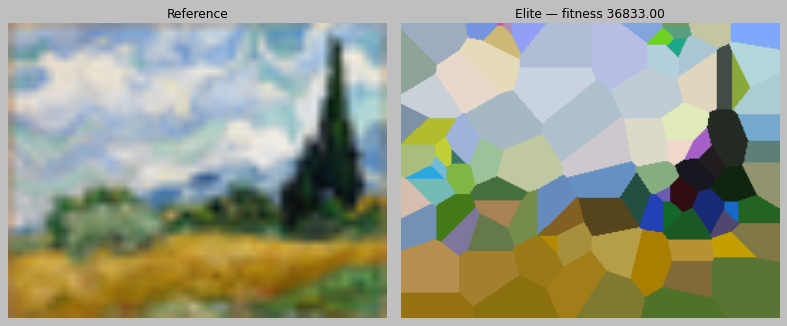

Generation  : 500
Elite       : 36833.0000  (best ever: 36833.0000)
Population  : avg 37637.5900  |  worst 39392.0000
Spread      : 2559.0000
Points      : 100
Done: seed 0 - pop 100 - crossover UNIFORM - points 100 - init RANDOM - 40s
CPU times: user 20.5 s, sys: 9.3 s, total: 29.8 s
Wall time: 40.1 s


In [39]:
%%time
data = run_algorithm((0, 100, "UNIFORM", 100, 'RANDOM', 500))